# Substrate–Inhibitor 2D Demo

In this notebook, we simulate the substrate–inhibitor reaction–diffusion system in two spatial dimensions using the AB2–AM2 scheme.

The aim is to visualise how Turing instability produces spatial patterns from a small perturbation of the homogeneous steady state. Compared with the Schnakenberg system, this model includes a saturating inhibition term, which can make the resulting patterns more sensitive to parameter choice.

The observed pattern depends on:
- the diffusion ratio $d$,
- the parameters controlling the inhibition term,
- the domain size and aspect ratio,
- the unstable spatial modes selected by the dispersion relation,
- and the nonlinear interaction between growing modes.

In [1]:
import sys
import os
sys.path.append(os.path.abspath("../.."))

import numpy as np
import matplotlib.pyplot as plt

from src.solvers import AB2AM2Solver2D
from src.models import SubstrateInhibitorModel
from src.visualiser import plot_2D_both, plot_2D_U, plot_2D_cases, animate_2D_both

## 1. Single 2D simulation

We begin with a single two-dimensional simulation on a square domain. The initial condition is a small random perturbation of the homogeneous steady state.

As in the Schnakenberg case, random perturbations contain many spatial frequencies. The Turing mechanism amplifies unstable modes while stable modes decay. The final pattern is then shaped by nonlinear saturation and the rational inhibition term.

In [2]:
params = {
    "a": 150.0,
    "b": 100.0,
    "alpha": 1.5,
    "rho": 13.0,
    "K": 0.05,
    "gamma": 3.0,
    "d": 50.0
}

solver = AB2AM2Solver2D(
    model=SubstrateInhibitorModel,
    params=params,
    Lx=100,
    Ly=100,
    Nx=200,
    Ny=200,
    T=100,
    dt=0.01,
    save_every=20
)

t, U, V, x, y, X, Y = solver.run(p_type="random")

print("Ran successfully:", U.shape)

Ran successfully: (501, 200, 200)


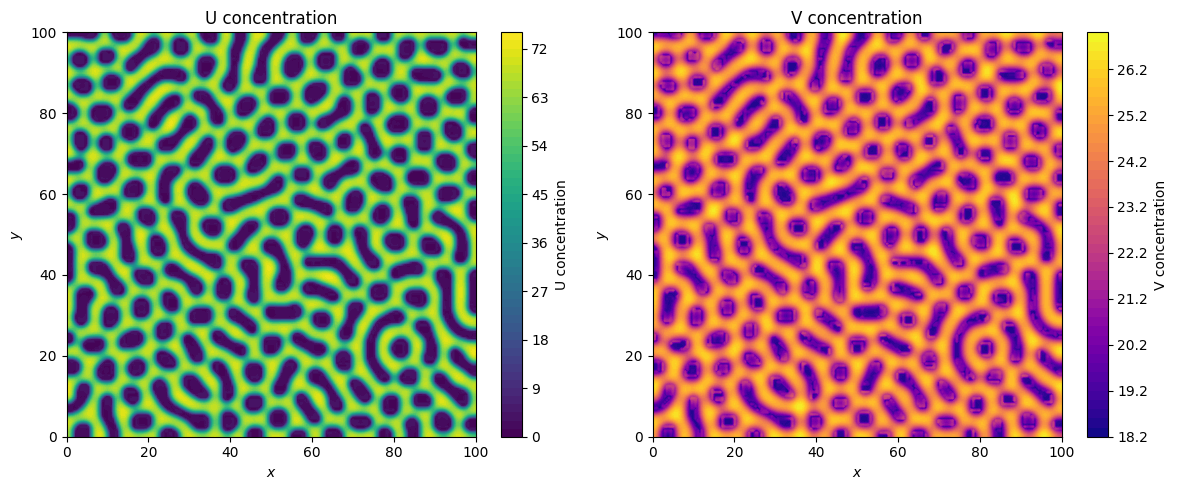

In [3]:
plot_2D_both(X, Y, U[-1], V[-1])

## 2. Pattern morphology

We now compare three representative substrate–inhibitor simulations. The goal is not to classify every possible pattern, but to show that the same model can produce different visible structures under different parameter and domain choices.

In these examples, we observe three typical behaviours:
- **spots**, where the pattern forms separated localised peaks,
- **bars**, where the structure aligns into banded regions,
- **maze-like patterns**, where competing modes produce more connected and irregular structures.

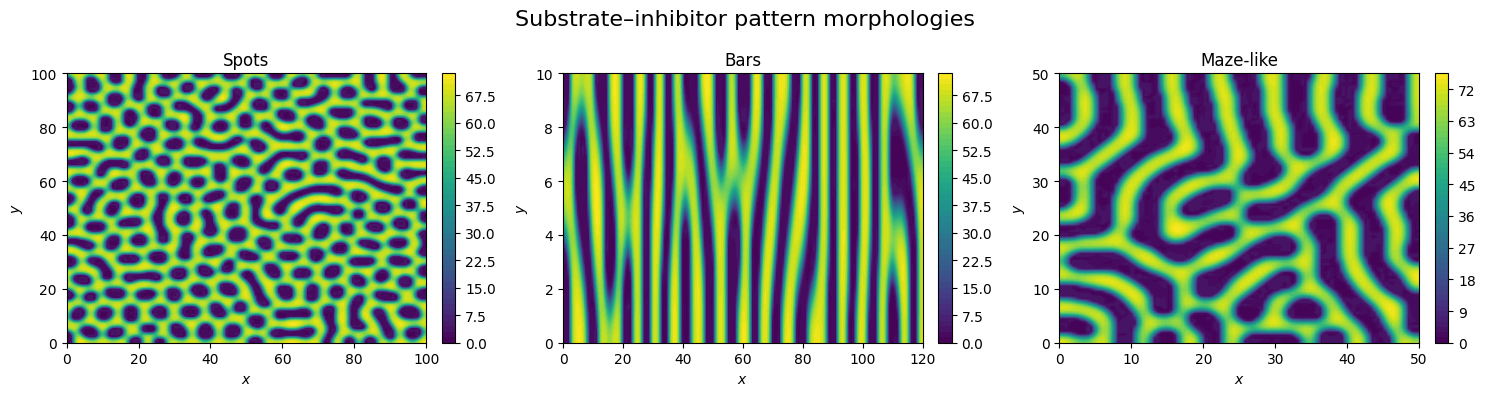

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Spots 
params = {
    "a": 150.0,
    "b": 100.0,
    "alpha": 1.5,
    "rho": 13.0,
    "K": 0.05,
    "gamma": 3.0,
    "d": 50.0
}

solver = AB2AM2Solver2D(
    model=SubstrateInhibitorModel,
    params=params,
    Lx=100, Ly=100,
    Nx=200, Ny=200,
    T=100,
    dt=0.01,
    save_every=20
)

t, U, V, x, y, X, Y = solver.run(p_type="random")
c1 = axes[0].contourf(X, Y, U[-1], cmap="viridis", levels=50)
axes[0].set_title("Spots")
axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel(r"$y$")
plt.colorbar(c1, ax=axes[0], fraction=0.046, pad=0.04)


# Bars 
params = {
    "a": 150.0,
    "b": 100.0,
    "alpha": 1.5,
    "rho": 13.0,
    "K": 0.05,
    "gamma": 3.0,
    "d": 50.0
}

solver = AB2AM2Solver2D(
    model=SubstrateInhibitorModel,
    params=params,
    Lx=120, Ly=10,
    Nx=180, Ny=30,
    T=250,
    dt=0.01,
    save_every=20
)

t, U, V, x, y, X, Y = solver.run(p_type="random")
c2 = axes[1].contourf(X, Y, U[-1], cmap="viridis", levels=50)
axes[1].set_title("Bars")
axes[1].set_xlabel(r"$x$")
axes[1].set_ylabel(r"$y$")
plt.colorbar(c2, ax=axes[1], fraction=0.046, pad=0.04)


# Maze-like pattern 
params = {
    "a": 160.0,
    "b": 110.0,
    "alpha": 1.5,
    "rho": 13.0,
    "K": 0.05,
    "gamma": 3.0,
    "d": 40.0
}

solver = AB2AM2Solver2D(
    model=SubstrateInhibitorModel,
    params=params,
    Lx=50, Ly=50,
    Nx=100, Ny=100,
    T=150,
    dt=0.01,
    save_every=50
)

t, U, V, x, y, X, Y = solver.run(p_type="random")
c3 = axes[2].contourf(X, Y, U[-1], cmap="viridis", levels=50)
axes[2].set_title("Maze-like")
axes[2].set_xlabel(r"$x$")
axes[2].set_ylabel(r"$y$")
plt.colorbar(c3, ax=axes[2], fraction=0.046, pad=0.04)


plt.suptitle("Substrate–inhibitor pattern morphologies", fontsize=16)
plt.tight_layout()
plt.show()

## 3. Comparing diffusion ratios

We now compare several diffusion ratios while keeping the reaction parameters fixed. This shows how the substrate–inhibitor patterns change as differential diffusion becomes stronger.

In [5]:
d_vals = [40, 50, 60]
results = {}

for d_val in d_vals:
    params = {
        "a": 160.0,
        "b": 110.0,
        "alpha": 1.5,
        "rho": 13.0,
        "K": 0.05,
        "gamma": 3.0,
        "d": d_val
    }

    solver = AB2AM2Solver2D(
        model=SubstrateInhibitorModel,
        params=params,
        Lx=50,
        Ly=50,
        Nx=100,
        Ny=100,
        T=150,
        dt=0.01,
        save_every=50
    )

    t, U, V, x, y, X, Y = solver.run(p_type="random")
    results[d_val] = (X, Y, U[-1], V[-1])

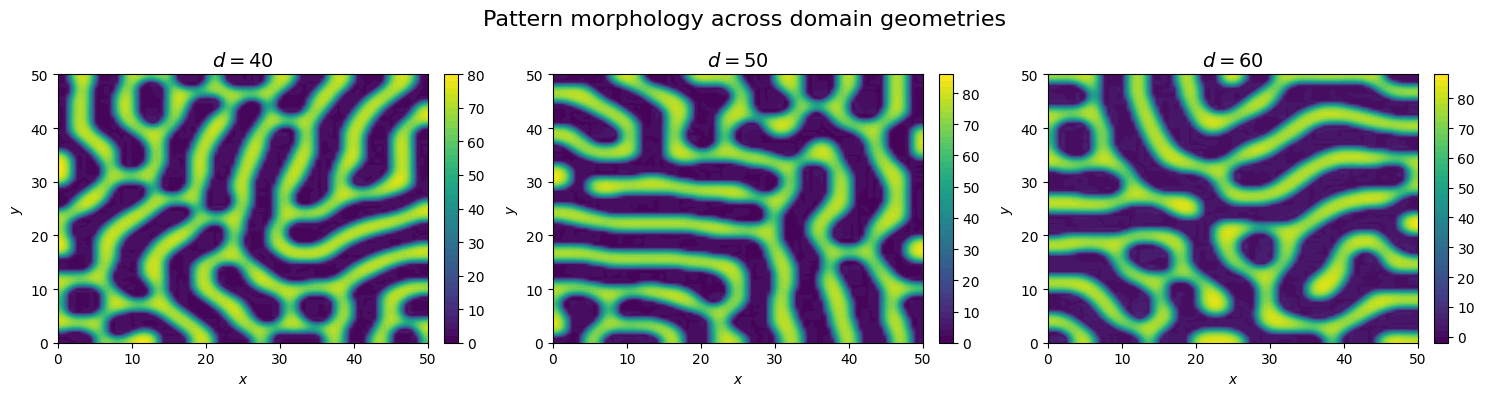

In [6]:
cases = []

for d_val in d_vals:
    X, Y, U_final, V_final = results[d_val]
    cases.append((X, Y, U_final, fr"$d = {d_val}$"))

plot_2D_cases(cases)

## 4. Animation

Finally, we save a GIF of the evolving $U$ and $V$ fields. This visualises how the initial perturbation is amplified and reorganised into a spatial pattern.

In [8]:
params = {
    "a": 160.0,
    "b": 110.0,
    "alpha": 1.5,
    "rho": 13.0,
    "K": 0.05,
    "gamma": 3.0,
    "d": 50.0
}

solver = AB2AM2Solver2D(
    model=SubstrateInhibitorModel,
    params=params,
    Lx=50,
    Ly=50,
    Nx=100,
    Ny=100,
    T=150,
    dt=0.01,
    save_every=10
)

t, U_hist, V_hist, x, y, X, Y = solver.run(p_type="random")

animate_2D_both(
    X,
    Y,
    U_hist,
    V_hist,
    filename="../../outputs/gifs/substrate_inhibitor_2D_both.gif",
    fps=8,
    title="Substrate–inhibitor reaction–diffusion dynamics"
)

## 5. Conclusion

The substrate–inhibitor simulations show that the model can produce a range of spatial structures, including spots, bars, and more irregular, maze-like patterns.

Compared with the Schnakenberg system, the patterns here appear more sensitive to parameter choice and domain geometry. This is partly due to the form of the reaction terms, which introduce stronger nonlinear interactions. As a result, smaller time steps are required for stable numerical simulation, but the resulting patterns are often more intricate and less regular than simple spot or stripe configurations.

Overall, these simulations highlight how the same underlying reaction–diffusion mechanism can generate diverse patterns, with the final structure determined by the interaction between diffusion, domain constraints, and nonlinear effects.